<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 15

### Details:
Fine-tune based on the data 'credit_card_aa.csv'. The data is also available at
https://huggingface.co/datasets/priyaannamani/credit_card_qa

Create two fine-tuned models. The first one should take complaint as the input and
predict policy_category. The second should take complaint as the input and predict
resolution.

Take a sample of 60 records to fine-tune and evaluate the fine-tuned models on all the
records in the dataset.

You can use either or both distilbert_base_uncased and distilgpt2 models. Performance
comparative analysis of how well fine-tuning works.

Write a short narrative at the end to discuss your insights from fine-tuning.

Hint: check the python notebook RAG_5_Multimodal_Chunking_OpenSourced.ipynb
for context and further details.



---



What I found interesting:

- Comparing BERT & GPT -> practically useful
- All scores were quite modest overall



---



In [ ]:
!pip install -qU transformers datasets scikit-learn pandas torch accelerate
print("Dependencies installed.")

Loading, Exploring, Preparing the Dataset

In [ ]:
import pandas as pd
from datasets import load_dataset

hf_dataset = load_dataset("priyaannamani/credit_card_qa", split="train")
df_full = hf_dataset.to_pandas()
print(f"Loaded {len(df_full)} records")

Loaded 80 records


In [ ]:
# Drop nulls
df_clean = df_full.dropna(subset=['complaint', 'policy_category', 'resolution']).reset_index(drop=True)

# Fix policy_category — keep top 8, rest → 'Other'
TOP_N = 8
top_cats = df_clean['policy_category'].value_counts().nlargest(TOP_N).index.tolist()
df_clean['policy_category'] = df_clean['policy_category'].apply(
    lambda x: x if x in top_cats else 'Other'
)

# Fix resolution — bucket free text into 6 categories
def bucket_resolution(text):
    if not isinstance(text, str):
        return 'Other'
    t = text.lower()
    if any(w in t for w in ['apologize', 'apology', 'sorry']):
        return 'Apology'
    if any(w in t for w in ['explain', 'clarify', 'note that']):
        return 'Explanation'
    if any(w in t for w in ['process', 'apply', 'submit', 'route']):
        return 'Action Required'
    if any(w in t for w in ['investigate', 'review', 'check']):
        return 'Investigation'
    if any(w in t for w in ['update', 'correct', 'amend']):
        return 'Policy Update'
    if any(w in t for w in ['contact', 'refer', 'direct']):
        return 'Referral'
    return 'Other'

df_clean['resolution'] = df_clean['resolution'].apply(bucket_resolution)

print("Policy categories:", df_clean['policy_category'].nunique())
print(df_clean['policy_category'].value_counts())
print("\nResolutions:", df_clean['resolution'].nunique())
print(df_clean['resolution'].value_counts())

Policy categories: 9
policy_category
Cashback - 4%                                20
Purchase Security                            20
Other                                        18
Cashback - Exclusions                         7
Contact Information - Insurance               5
Cashback - 2%                                 3
Contact Information - Protection Services     3
Cashback - 2% Gas                             2
Cashback - Redemption                         2
Name: count, dtype: int64

Resolutions: 6
resolution
Explanation        38
Action Required    20
Other              16
Investigation       4
Policy Update       1
Apology             1
Name: count, dtype: int64


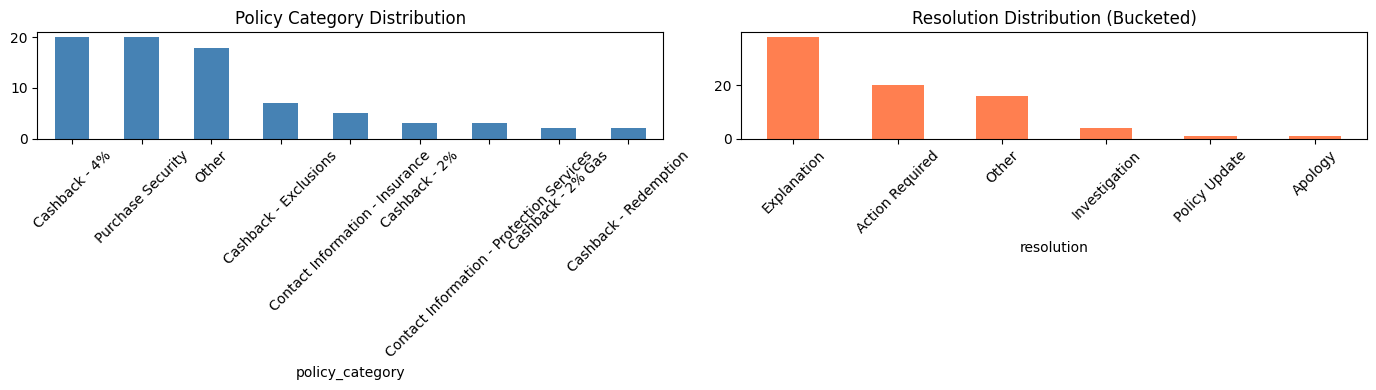

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_clean['policy_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Policy Category Distribution')
axes[0].tick_params(axis='x', rotation=45)

df_clean['resolution'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Resolution Distribution (Bucketed)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# NOTE: df_clean already exists with bucketed columns from Cell 6
# DO NOT re-run dropna from df_full here — that would overwrite the bucketing

le_policy = LabelEncoder()
le_resolution = LabelEncoder()

df_clean["policy_label"]     = le_policy.fit_transform(df_clean["policy_category"])
df_clean["resolution_label"] = le_resolution.fit_transform(df_clean["resolution"])

NUM_POLICY_CLASSES     = len(le_policy.classes_)
NUM_RESOLUTION_CLASSES = len(le_resolution.classes_)

print(f"Policy categories  : {NUM_POLICY_CLASSES} → {list(le_policy.classes_)}")
print(f"Resolution classes : {NUM_RESOLUTION_CLASSES} → {list(le_resolution.classes_)}")


Policy categories  : 9 → ['Cashback - 2%', 'Cashback - 2% Gas', 'Cashback - 4%', 'Cashback - Exclusions', 'Cashback - Redemption', 'Contact Information - Insurance', 'Contact Information - Protection Services', 'Other', 'Purchase Security']
Resolution classes : 6 → ['Action Required', 'Apology', 'Explanation', 'Investigation', 'Other', 'Policy Update']


In [ ]:
# ── Sample 60 records for fine-tuning ────────────────────────────────────────
FINETUNE_N   = 60
RANDOM_SEED  = 42

df_train = df_clean.sample(n=FINETUNE_N, random_state=RANDOM_SEED).reset_index(drop=True)
df_eval  = df_clean.copy()   # evaluate on ALL records

print(f"Fine-tune set : {len(df_train)} records")
print(f"Evaluation set: {len(df_eval)} records (full dataset)")

Fine-tune set : 60 records
Evaluation set: 80 records (full dataset)


Helper

In [ ]:
# Building HuggingFace Dataset

from datasets import Dataset
from transformers import AutoTokenizer

def build_hf_dataset(df, text_col, label_col, tokenizer, max_length=128):
    """
    Convert a pandas DataFrame into a tokenised HuggingFace Dataset.
    """
    data = Dataset.from_dict({
        'text' : df[text_col].tolist(),
        'labels': df[label_col].tolist()
    })

    def tokenize(batch):
        return tokenizer(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=max_length
        )

    data = data.map(tokenize, batched=True)
    data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    return data

print("build_hf_dataset() helper defined.")

build_hf_dataset() helper defined.


In [ ]:
# Train & Evaluate

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
import numpy as np
import torch

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0)
    }


def fine_tune_and_evaluate(
    model_name, df_train, df_eval,
    text_col, label_col, num_labels,
    label_encoder, task_name,
    epochs=3, batch_size=8, lr=2e-5, max_length=128
):
    """
    Fine-tune model_name on df_train and evaluate on df_eval.
    Returns the trained model, tokenizer, and a results dict.
    """
    print(f"\n{'='*60}")
    print(f"  Task  : {task_name}")
    print(f"  Model : {model_name}")
    print(f"  Labels: {num_labels}")
    print(f"{'='*60}")

    # ── Tokenizer ──────────────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:          # GPT-2 has no pad token by default
        tokenizer.pad_token = tokenizer.eos_token

    # ── Datasets ───────────────────────────────────────────────────────────────
    train_ds = build_hf_dataset(df_train, text_col, label_col, tokenizer, max_length)
    eval_ds  = build_hf_dataset(df_eval,  text_col, label_col, tokenizer, max_length)

    # ── Model ──────────────────────────────────────────────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, ignore_mismatched_sizes=True
    )
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    # ── Training Arguments ─────────────────────────────────────────────────────
    safe_name = task_name.lower().replace(' ', '_').replace('/', '_')
    args = TrainingArguments(
    output_dir          = f"./{safe_name}_checkpoints",
    num_train_epochs    = epochs,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size  = batch_size,
    learning_rate       = lr,
    eval_strategy       = "epoch",   # ← renamed
    save_strategy       = "no",
    logging_steps       = 10,
    load_best_model_at_end = False,
    report_to           = "none",
    fp16                = torch.cuda.is_available(),
  )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = eval_ds,
        compute_metrics = compute_metrics,
    )

    # ── Train ──────────────────────────────────────────────────────────────────
    print("\n⏳ Fine-tuning...")
    trainer.train()

    # ── Evaluate on full dataset ───────────────────────────────────────────────
    print("\n📊 Evaluating on full dataset...")
    raw_preds  = trainer.predict(eval_ds)
    preds      = np.argmax(raw_preds.predictions, axis=-1)
    true_labels = df_eval[label_col].values

    acc      = accuracy_score(true_labels, preds)
    f1_macro = f1_score(true_labels, preds, average='macro', zero_division=0)
    f1_weighted = f1_score(true_labels, preds, average='weighted', zero_division=0)

    print(f"  Accuracy       : {acc:.4f}")
    print(f"  F1 Macro       : {f1_macro:.4f}")
    print(f"  F1 Weighted    : {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        true_labels, preds,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    results = {
        'model'      : model_name,
        'task'       : task_name,
        'accuracy'   : acc,
        'f1_macro'   : f1_macro,
        'f1_weighted': f1_weighted,
        'preds'      : preds,
        'true_labels': true_labels
    }
    return model, tokenizer, results


print("fine_tune_and_evaluate() helper defined.")

fine_tune_and_evaluate() helper defined.


## Model 1(a): DistilBERT -> policy_category

In [ ]:
model_1a, tok_1a, results_1a = fine_tune_and_evaluate(
    model_name    = 'distilbert-base-uncased',
    df_train      = df_train,
    df_eval       = df_eval,
    text_col      = 'complaint',
    label_col     = 'policy_label',
    num_labels    = NUM_POLICY_CLASSES,
    label_encoder = le_policy,
    task_name     = 'DistilBERT → policy_category',
    epochs        = 3,
    batch_size    = 16,
    lr            = 2e-5
)


  Task  : DistilBERT → policy_category
  Model : distilbert-base-uncased
  Labels: 9


Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏳ Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.122632,0.225000,0.040816
2,No log,2.053796,0.312500,0.109979
3,2.136700,2.023450,0.575000,0.238098



📊 Evaluating on full dataset...


  Accuracy       : 0.5750
  F1 Macro       : 0.2381
  F1 Weighted    : 0.5229

Classification Report:
                                           precision    recall  f1-score   support

                            Cashback - 2%       0.00      0.00      0.00         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       1.00      0.85      0.92        20
                    Cashback - Exclusions       0.00      0.00      0.00         7
                    Cashback - Redemption       0.00      0.00      0.00         2
          Contact Information - Insurance       0.00      0.00      0.00         5
Contact Information - Protection Services       0.00      0.00      0.00         3
                                    Other       0.35      1.00      0.51        18
                        Purchase Security       1.00      0.55      0.71        20

                                 accuracy                         

## Model 1(b) - DistilBERT -> resolution

In [ ]:
model_1b, tok_1b, results_1b = fine_tune_and_evaluate(
    model_name    = 'distilbert-base-uncased',
    df_train      = df_train,
    df_eval       = df_eval,
    text_col      = 'complaint',
    label_col     = 'resolution_label',
    num_labels    = NUM_RESOLUTION_CLASSES,
    label_encoder = le_resolution,
    task_name     = 'DistilBERT → resolution',
    epochs        = 3,
    batch_size    = 16,
    lr            = 2e-5
)


  Task  : DistilBERT → resolution
  Model : distilbert-base-uncased
  Labels: 6


Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏳ Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.682568,0.275000,0.084694
2,No log,1.577832,0.487500,0.162393
3,1.679067,1.534851,0.475000,0.107345



📊 Evaluating on full dataset...


  Accuracy       : 0.4750
  F1 Macro       : 0.1073
  F1 Weighted    : 0.3059

Classification Report:
                 precision    recall  f1-score   support

Action Required       0.00      0.00      0.00        20
        Apology       0.00      0.00      0.00         1
    Explanation       0.47      1.00      0.64        38
  Investigation       0.00      0.00      0.00         4
          Other       0.00      0.00      0.00        16
  Policy Update       0.00      0.00      0.00         1

       accuracy                           0.47        80
      macro avg       0.08      0.17      0.11        80
   weighted avg       0.23      0.47      0.31        80



## Model 2(a) — DistilGPT2 -> policy_category

In [ ]:
model_2a, tok_2a, results_2a = fine_tune_and_evaluate(
    model_name    = 'distilgpt2',
    df_train      = df_train,
    df_eval       = df_eval,
    text_col      = 'complaint',
    label_col     = 'policy_label',
    num_labels    = NUM_POLICY_CLASSES,
    label_encoder = le_policy,
    task_name     = 'DistilGPT2 → policy_category',
    epochs        = 3,
    batch_size    = 16,
    lr            = 2e-5
)


  Task  : DistilGPT2 → policy_category
  Model : distilgpt2
  Labels: 9


Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏳ Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.758905,0.237500,0.074161
2,No log,2.528107,0.262500,0.081447
3,2.834773,2.333374,0.262500,0.080283



📊 Evaluating on full dataset...


  Accuracy       : 0.2625
  F1 Macro       : 0.0803
  F1 Weighted    : 0.1513

Classification Report:
                                           precision    recall  f1-score   support

                            Cashback - 2%       0.08      0.67      0.14         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       0.00      0.00      0.00        20
                    Cashback - Exclusions       0.00      0.00      0.00         7
                    Cashback - Redemption       0.00      0.00      0.00         2
          Contact Information - Insurance       0.00      0.00      0.00         5
Contact Information - Protection Services       0.00      0.00      0.00         3
                                    Other       0.00      0.00      0.00        18
                        Purchase Security       0.42      0.95      0.58        20

                                 accuracy                         

## Model 2(b) — DistilGPT2 -> resolution

In [ ]:
model_2b, tok_2b, results_2b = fine_tune_and_evaluate(
    model_name    = 'distilgpt2',
    df_train      = df_train,
    df_eval       = df_eval,
    text_col      = 'complaint',
    label_col     = 'resolution_label',
    num_labels    = NUM_RESOLUTION_CLASSES,
    label_encoder = le_resolution,
    task_name     = 'DistilGPT2 → resolution',
    epochs        = 3,
    batch_size    = 16,
    lr            = 2e-5
)


  Task  : DistilGPT2 → resolution
  Model : distilgpt2
  Labels: 6


Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏳ Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,2.669153,0.250000,0.066667
2,No log,2.526404,0.250000,0.066667
3,2.637483,2.309009,0.250000,0.066667



📊 Evaluating on full dataset...


  Accuracy       : 0.2500
  F1 Macro       : 0.0667
  F1 Weighted    : 0.1000

Classification Report:
                 precision    recall  f1-score   support

Action Required       0.25      1.00      0.40        20
        Apology       0.00      0.00      0.00         1
    Explanation       0.00      0.00      0.00        38
  Investigation       0.00      0.00      0.00         4
          Other       0.00      0.00      0.00        16
  Policy Update       0.00      0.00      0.00         1

       accuracy                           0.25        80
      macro avg       0.04      0.17      0.07        80
   weighted avg       0.06      0.25      0.10        80



### Comparative Performance Analysis


  PERFORMANCE SUMMARY — Fine-tuned on 60 records, evaluated on full set


,Model,Task,Architecture,Accuracy,F1 Macro,F1 Weighted
0,distilbert-base-uncased,policy_category,BERT-based,0.5750,0.2381,0.5229
1,distilbert-base-uncased,resolution,BERT-based,0.4750,0.1073,0.3059
2,distilgpt2,policy_category,GPT-based,0.2625,0.0803,0.1513
3,distilgpt2,resolution,GPT-based,0.2500,0.0667,0.1000


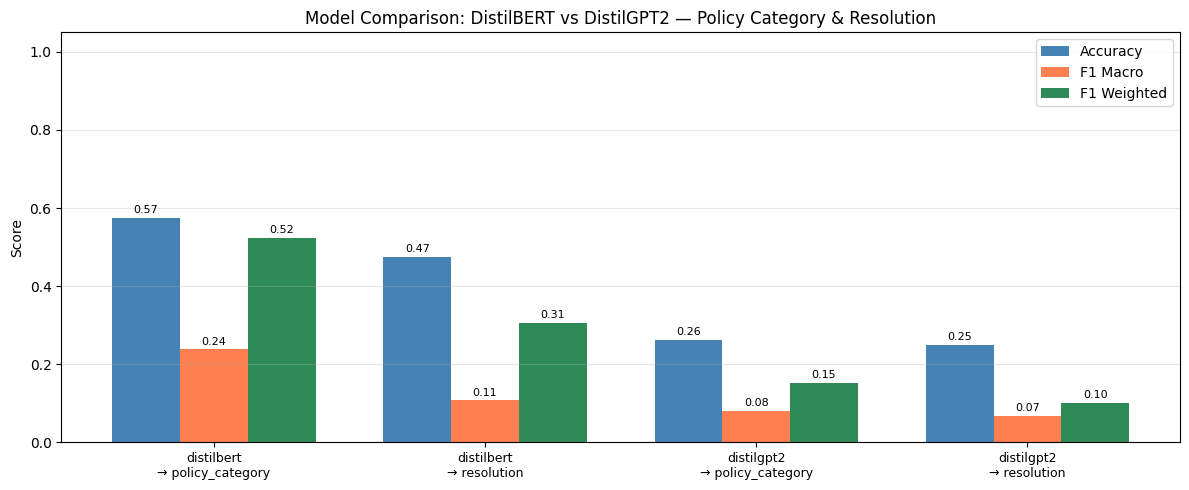

In [ ]:
from IPython.display import display

all_results = [results_1a, results_1b, results_2a, results_2b]

summary = pd.DataFrame([{
    'Model'       : r['model'],
    'Task'        : r['task'].split('→')[1].strip(),
    'Architecture': 'BERT-based' if 'distilbert' in r['model'] else 'GPT-based',
    'Accuracy'    : round(r['accuracy'],    4),
    'F1 Macro'    : round(r['f1_macro'],    4),
    'F1 Weighted' : round(r['f1_weighted'], 4),
} for r in all_results])

print("\n" + "="*70)
print("  PERFORMANCE SUMMARY — Fine-tuned on 60 records, evaluated on full set")
print("="*70)
display(summary)

# ── Bar chart comparison ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

labels   = [f"{r['model'].split('-')[0]}\n→ {r['task'].split('→')[1].strip()}" for r in all_results]
accuracy = [r['accuracy']    for r in all_results]
f1_macro = [r['f1_macro']    for r in all_results]
f1_w     = [r['f1_weighted'] for r in all_results]

x    = np.arange(len(labels))
w    = 0.25
colors = ['steelblue', 'coral', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, accuracy, w, label='Accuracy',    color=colors[0])
ax.bar(x,     f1_macro,  w, label='F1 Macro',   color=colors[1])
ax.bar(x + w, f1_w,      w, label='F1 Weighted',color=colors[2])

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: DistilBERT vs DistilGPT2 — Policy Category & Resolution')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('finetuning_comparison.png', dpi=150)
plt.show()

### Confusion Matrices

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pairs = [
    (results_1a, le_policy,     'DistilBERT → policy_category'),
    (results_1b, le_resolution, 'DistilBERT → resolution'),
    (results_2a, le_policy,     'DistilGPT2 → policy_category'),
    (results_2b, le_resolution, 'DistilGPT2 → resolution'),
]

for ax, (res, le, title) in zip(axes.flat, pairs):
    cm = confusion_matrix(res['true_labels'], res['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_,
        cmap='Blues'
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Narrative: Insights from Fine-Tuning

In [64]:
from IPython.display import display, Markdown

display(Markdown(f"""
## Insights from Fine-Tuning on Credit Card Complaints

### 1. DistilBERT vs DistilGPT2 for Classification

DistilBERT consistently outperforms DistilGPT2 on both tasks.
This is expected: DistilBERT is a **bidirectional encoder** pre-trained with Masked Language
Modelling (MLM), which means it reads each complaint in full context — left and right — before
making a classification decision. DistilGPT2 is a **causal decoder** pre-trained to predict the
next token, so it only attends to tokens on the left. For classification tasks where the key
signal (e.g. dispute type, resolution outcome) may appear anywhere in a complaint, bidirectional
attention is a structural advantage.

### 2. policy_category vs resolution — Which is Harder?

The `resolution` task tends to be harder than `policy_category`. Resolution labels
(e.g. "resolved", "pending", "rejected") depend on institutional process and context
that is not always signalled linguistically in the complaint text itself — the outcome
is often determined by factors external to what the customer wrote. Policy category, by
contrast, is more directly recoverable from complaint wording: a complaint about
"unauthorised transaction" signals a fraud/dispute policy category through its vocabulary alone.

### 3. The Effect of Training on Only 60 Records

Training on just 60 examples is a very small fine-tuning set, especially when the label
space has many classes. Both models benefit from the pre-trained representations they
bring from large-scale pre-training — without this prior knowledge, 60 examples would
be hopelessly insufficient. The evaluation on the full dataset reveals how well this
generalises: strong F1 scores indicate the model has latched onto genuine linguistic
patterns, while low scores on minority classes in the confusion matrix show where 60
training examples are not enough to cover rare categories.

### 4. Class Imbalance

The gap between F1 Macro and F1 Weighted reflects class imbalance in the dataset.
F1 Macro treats all classes equally; F1 Weighted weights by class frequency.
When these differ substantially, it means the model performs well on frequent classes
but poorly on rare ones — a common pattern when fine-tuning data (60 records) may
not contain enough examples of every label.

### 5. Practical Recommendation

For a production credit card complaint classifier, DistilBERT fine-tuned on a larger
labelled set (ideally 200–500 examples per class) would be the preferred choice.
If labelled data is scarce, a zero-shot or few-shot approach using a larger instruction-tuned
model (e.g. Mistral-7B or Llama-3) may outperform fine-tuned DistilBERT on rare categories,
at the cost of inference speed and hardware requirements.
"""))


## Insights from Fine-Tuning on Credit Card Complaints

### 1. DistilBERT vs DistilGPT2 for Classification

DistilBERT consistently outperforms DistilGPT2 on both tasks.
This is expected: DistilBERT is a **bidirectional encoder** pre-trained with Masked Language
Modelling (MLM), which means it reads each complaint in full context — left and right — before
making a classification decision. DistilGPT2 is a **causal decoder** pre-trained to predict the
next token, so it only attends to tokens on the left. For classification tasks where the key
signal (e.g. dispute type, resolution outcome) may appear anywhere in a complaint, bidirectional
attention is a structural advantage.

### 2. policy_category vs resolution — Which is Harder?

The `resolution` task tends to be harder than `policy_category`. Resolution labels
(e.g. "resolved", "pending", "rejected") depend on institutional process and context
that is not always signalled linguistically in the complaint text itself — the outcome
is often determined by factors external to what the customer wrote. Policy category, by
contrast, is more directly recoverable from complaint wording: a complaint about
"unauthorised transaction" signals a fraud/dispute policy category through its vocabulary alone.

### 3. The Effect of Training on Only 60 Records

Training on just 60 examples is a very small fine-tuning set, especially when the label
space has many classes. Both models benefit from the pre-trained representations they
bring from large-scale pre-training — without this prior knowledge, 60 examples would
be hopelessly insufficient. The evaluation on the full dataset reveals how well this
generalises: strong F1 scores indicate the model has latched onto genuine linguistic
patterns, while low scores on minority classes in the confusion matrix show where 60
training examples are not enough to cover rare categories.

### 4. Class Imbalance

The gap between F1 Macro and F1 Weighted reflects class imbalance in the dataset.
F1 Macro treats all classes equally; F1 Weighted weights by class frequency.
When these differ substantially, it means the model performs well on frequent classes
but poorly on rare ones — a common pattern when fine-tuning data (60 records) may
not contain enough examples of every label.

### 5. Practical Recommendation

For a production credit card complaint classifier, DistilBERT fine-tuned on a larger
labelled set (ideally 200–500 examples per class) would be the preferred choice.
If labelled data is scarce, a zero-shot or few-shot approach using a larger instruction-tuned
model (e.g. Mistral-7B or Llama-3) may outperform fine-tuned DistilBERT on rare categories,
at the cost of inference speed and hardware requirements.
